# Customer Segmentation using K-Means Clustering

## Project Objective

The objective of this project is to segment customers into distinct groups based on their demographic and spending behavior using unsupervised machine learning techniques.

The project applies Principal Component Analysis (PCA) for dimensionality reduction and K-Means Clustering for identifying hidden customer groups. The resulting clusters are analyzed to generate meaningful customer personas that can support business decision-making and targeted marketing strategies.

### Key Techniques Used

- Data Preprocessing
- Label Encoding
- Feature Scaling
- Principal Component Analysis (PCA)
- K-Means Clustering
- Elbow Method
- Silhouette Score Evaluation
- Customer Persona Analysis

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

## Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Kavya\OneDrive\Desktop\decodelabs_tasks\Project_2_Customer_Segmentation\data\Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Overview

In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Preprocessing

In [7]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## Feature Selection

In [8]:
X = df.drop("CustomerID", axis=1)

## Feature Scaling

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Principal Component Analysis (PCA)

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(200, 2)


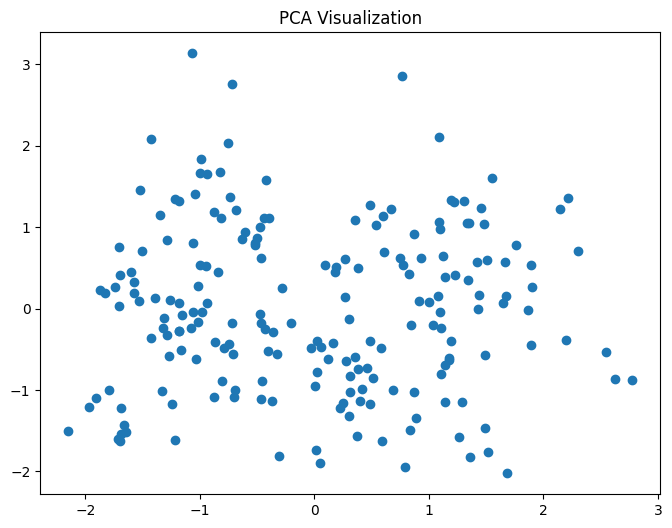

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

plt.title("PCA Visualization")
plt.show()

In [12]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

## Elbow Method

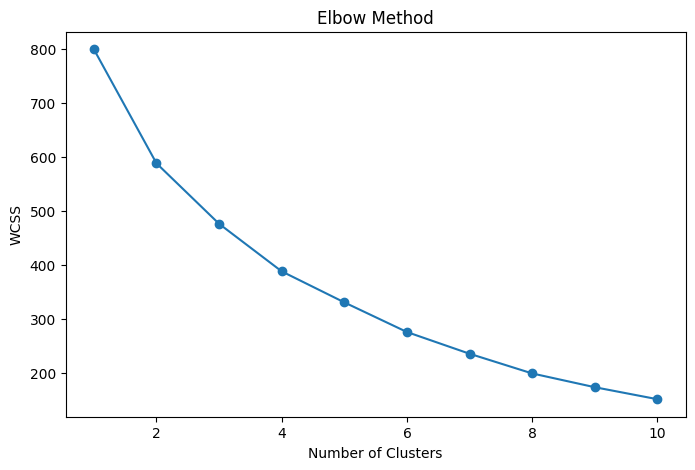

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

## K-Means Clustering

In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

## Silhouette Score Evaluation

In [15]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.3040600988258827


## Cluster Visualization

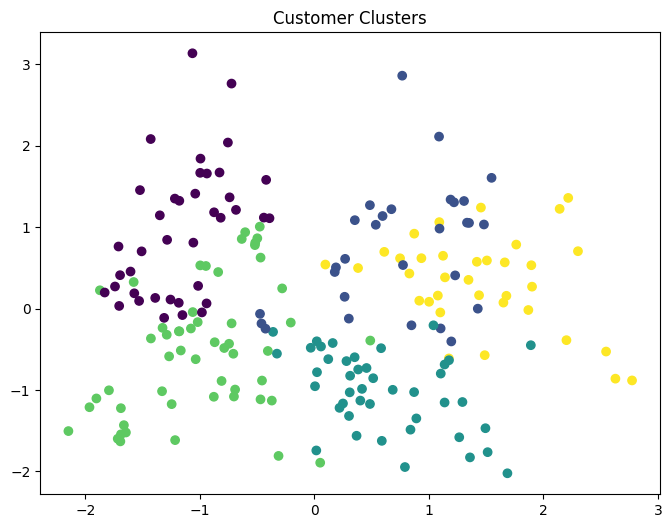

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("Customer Clusters")

plt.show()

## Customer Personas

In [17]:
persona = df.groupby("Cluster").mean()

persona

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.000000,0.461538,32.692308,86.538462,82.128205
1,165.482759,0.448276,36.482759,89.517241,18.000000
2,73.651163,0.000000,49.813953,49.232558,40.069767
3,52.814815,0.407407,24.907407,39.722222,61.203704
4,84.685714,1.000000,55.714286,53.685714,36.771429


## Export Processed Dataset

In [18]:
df.to_csv(
    "cleaned_data.csv",
    index=False
)

# Conclusion

This project successfully applied customer segmentation techniques using K-Means Clustering and Principal Component Analysis (PCA).

### Accomplishments

- Loaded and explored customer data
- Performed data preprocessing and encoding
- Applied feature scaling
- Reduced dimensionality using PCA
- Determined optimal clusters using the Elbow Method
- Evaluated cluster quality using Silhouette Score
- Visualized customer segments
- Generated customer personas
- Exported the final segmented dataset

The resulting customer groups provide valuable insights into customer behavior and can assist businesses in developing personalized marketing strategies and improving customer engagement.